In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Exporting model
import joblib
from ipywidgets import interact, IntSlider, Dropdown


In [2]:
# Load the Excel file
file_path = "/kaggle/input/ghgases/af60b10b8dad38110304 (1).xlsx"
excel_file = pd.ExcelFile(file_path)

# Filter only relevant 'Summary_Commodity' sheets (2010–2016)
summary_commodity_sheets = [
    sheet for sheet in excel_file.sheet_names
    if 'Summary_Commodity' in sheet and sheet[:4].isdigit()
]

# Combine data from all relevant sheets
df_summary_commodity = pd.concat([
    pd.read_excel(file_path, sheet_name=sheet).assign(Year=int(sheet[:4]))
    for sheet in summary_commodity_sheets
], ignore_index=True)

# Preview
df_summary_commodity.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Commodity Code,Commodity Name,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Unnamed: 7,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Year
0,111CA,Farms,carbon dioxide,"kg/2018 USD, purchaser price",0.467,0.046,0.513,NaN,4,2,1,4,1,2016
1,111CA,Farms,methane,"kg/2018 USD, purchaser price",0.025,0.000,0.026,NaN,3,2,1,1,1,2016
2,111CA,Farms,nitrous oxide,"kg/2018 USD, purchaser price",0.002,0.000,0.002,NaN,4,2,1,4,1,2016
3,111CA,Farms,other GHGs,"kg CO2e/2018 USD, purchaser price",0.004,0.000,0.004,NaN,4,2,1,4,1,2016
4,113FF,"Forestry, fishing, and related activities",carbon dioxide,"kg/2018 USD, purchaser price",0.199,0.024,0.223,NaN,4,2,1,4,1,2016


In [3]:
# Rename for easier access
df = df_summary_commodity.rename(columns={
    'Commodity Code': 'CommodityCode',
    'Commodity Name': 'CommodityName',
    'Supply Chain Emission Factors with Margins': 'GHG_Factor',
    'Substance': 'GHG_Type'
})

# Keep relevant columns
df = df[['Year', 'CommodityCode', 'CommodityName', 'GHG_Type', 'GHG_Factor']]

# Pivot GHG types into columns
df_pivot = df.pivot_table(
    index=['Year', 'CommodityCode', 'CommodityName'],
    columns='GHG_Type',
    values='GHG_Factor',
    aggfunc='first'
).reset_index()

# Fill missing values with 0
df_pivot = df_pivot.fillna(0)

# Calculate Total CO2-equivalent using GWP factors
df_pivot['Total_CO2e'] = (
    df_pivot.get('carbon dioxide', 0) +
    df_pivot.get('methane', 0) * 25 +
    df_pivot.get('nitrous oxide', 0) * 298 +
    df_pivot.get('other GHGs', 0)
)


In [4]:
# Encode commodity code and name
le_code = LabelEncoder()
le_name = LabelEncoder()

df_pivot['CommodityCode_enc'] = le_code.fit_transform(df_pivot['CommodityCode'])
df_pivot['CommodityName_enc'] = le_name.fit_transform(df_pivot['CommodityName'])

# Define features and target
features = ['Year', 'CommodityCode_enc', 'CommodityName_enc']
target = 'Total_CO2e'

X = df_pivot[features]
y = df_pivot[target]


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)


MAE: 0.04341935483870967
R² Score: 0.9824076922734298


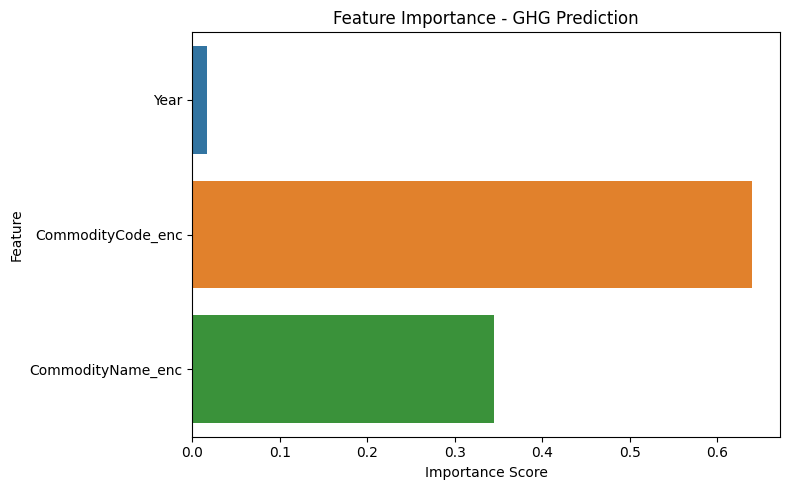

In [6]:
# Plot feature importance
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance - GHG Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [7]:
# Forecast emissions for 2017–2020
future_years = [2017, 2018, 2019, 2020]
future_data = []

for year in future_years:
    for code, name in zip(df_pivot['CommodityCode'].unique(), df_pivot['CommodityName'].unique()):
        future_data.append([
            year,
            le_code.transform([code])[0],
            le_name.transform([name])[0]
        ])

# Create DataFrame
df_future = pd.DataFrame(future_data, columns=['Year', 'CommodityCode_enc', 'CommodityName_enc'])

# Predict emissions
df_future['Predicted_Total_CO2e'] = model.predict(df_future)

# View predictions
df_future.head()


,Year,CommodityCode_enc,CommodityName_enc,Predicted_Total_CO2e
0,2017,0,15,1.71408
1,2017,1,20,0.39036
2,2017,2,38,1.20969
3,2017,3,30,1.31366
4,2017,4,56,0.73973


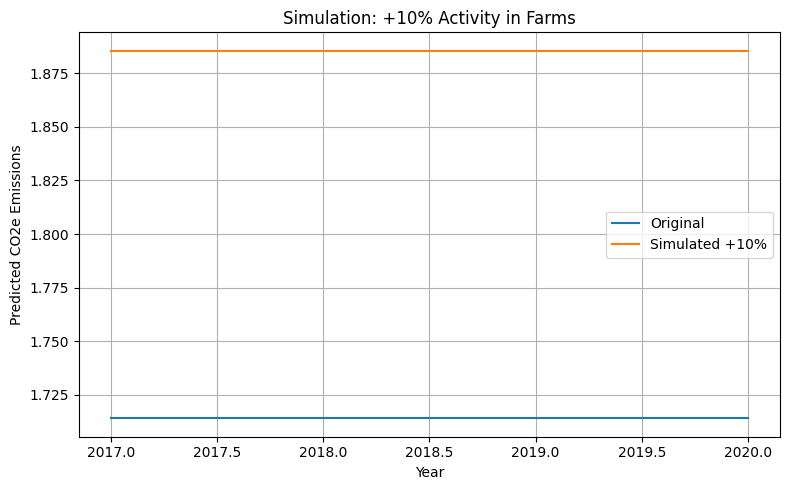

In [8]:
# Copy original prediction
df_simulated = df_future.copy()

# Find encoded value for a specific commodity (e.g. '111CA' - Farms)
target_code = le_code.transform(['111CA'])[0]  # Replace with actual code if needed

# Simulate +10% increase
df_simulated.loc[df_simulated['CommodityCode_enc'] == target_code, 'Predicted_Total_CO2e'] *= 1.10

# Compare original vs simulated
comparison = df_simulated[df_simulated['CommodityCode_enc'] == target_code][['Year', 'Predicted_Total_CO2e']]
comparison.columns = ['Year', 'Simulated_CO2e']

actual = df_future[df_future['CommodityCode_enc'] == target_code][['Year', 'Predicted_Total_CO2e']]
actual.columns = ['Year', 'Original_CO2e']

result = actual.merge(comparison, on='Year')

# Plot
plt.figure(figsize=(8, 5))
plt.plot(result['Year'], result['Original_CO2e'], label='Original')
plt.plot(result['Year'], result['Simulated_CO2e'], label='Simulated +10%')
plt.title("Simulation: +10% Activity in Farms")
plt.ylabel("Predicted CO2e Emissions")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# Save trained model
joblib.dump(model, "ghg_rf_model.pkl")

# Save future predictions
df_future.to_csv("future_ghg_predictions.csv", index=False)


In [10]:
from IPython.display import FileLink
FileLink('ghg_rf_model.pkl')  # to download your model
FileLink('future_ghg_predictions.csv')  # to download forecast data


/kaggle/working/future_ghg_predictions.csv

In [13]:
# Interactive function
def display_forecast(year, code_enc, change_pct):
    subset = df_future[
        (df_future['Year'] == year) & 
        (df_future['CommodityCode_enc'] == code_enc)
    ]
    
    if not subset.empty:
        base = subset.iloc[0]['Predicted_Total_CO2e']
        adjusted = base * (1 + change_pct / 100)
        
        print(f"Predicted Emissions (CO₂e): {base:,.2f} tonnes")
        print(f"Simulated Emissions (+{change_pct}%): {adjusted:,.2f} tonnes")
        
        # Bar chart
        plt.figure(figsize=(5, 4))
        sns.barplot(x=["Original", "Simulated"], y=[base, adjusted], palette="pastel")
        plt.title(f"GHG Emissions Simulation ({year})")
        plt.ylabel("CO₂e Tonnes")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    else:
        print("No data available for this selection.")

# Widgets
year_slider = IntSlider(min=2017, max=2020, step=1, value=2017, description='Year:')
commodity_dropdown = Dropdown(
    options=sorted(df_future['CommodityCode_enc'].unique()), 
    value=0,
    description='Commodity:'
)
change_slider = IntSlider(min=-50, max=100, step=10, value=0, description='% Change:')

# Bind interactivity
interact(display_forecast, year=year_slider, code_enc=commodity_dropdown, change_pct=change_slider);


interactive(children=(IntSlider(value=2017, description='Year:', max=2020, min=2017), Dropdown(description='Co…